In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Временные ряды

Временные ряды — это наборы данных, где каждая точка данных связана с определенным моментом времени. Это может быть что угодно, от ежедневных финансовых показателей до ежечасных кликов на веб-сайте или даже месячных показателей погоды. 

Области, где временные ряды играют решающую роль:

1. Финансовая аналитика: Прогнозирование цен акций, анализ рыночных тенденций и определение оптимального времени для инвестиций.

2. Маркетинг и анализ пользовательской активности: Отслеживание изменений в поведении пользователей на веб-сайте, прогнозирование спроса на товары и услуги.

3. Прогнозирование спроса: Определение оптимального уровня запасов, чтобы избежать дефицита или избытка товаров.

4. Анализ временных данных о заболеваниях: Оценка распространения эпидемий, прогнозирование заболеваемости и смертности.

5. Климатические исследования: Изучение изменений в климатических параметрах, таких как температура и осадки, для анализа климатических тенденций.

6. Прогнозирование трафика: Анализ и прогнозирование трафика на веб-сайтах и в сетях.

7. Промышленное оборудование и обслуживание: Предсказание времени отказа оборудования и оптимизация производственных процессов.


Временные ряды могут быть стационарными (когда статистические характеристики, такие как среднее и дисперсия, остаются постоянными во времени) или нестационарными (когда эти характеристики изменяются с течением времени). Понимание природы временного ряда важно для выбора подходящих методов анализа.

## Основные характеристики временных рядов

__Тренд__: Тренд представляет собой долгосрочное изменение в данных. Это может быть рост или спад. Например, если продажи вашей компании растут каждый месяц в течение года, это будет проявление тренда.

__Сезонность__: Сезонность — это циклические изменения данных, которые повторяются с постоянным интервалом времени. Например, продажи игрушек могут расти перед праздниками и падать после них.

__Шум__: Шум представляет собой случайные колебания данных, которые не подчиняются определенным закономерностям. Это может быть вызвано различными факторами, такими как случайные события или ошибки измерения.

__Циклы__: Циклы — это долгосрочные колебания данных, которые не связаны с сезонностью. Например, экономические циклы могут вызывать волны роста и спада в продажах.

__Стационарность__: Стационарный временной ряд — это ряд, в котором статистические характеристики, такие как среднее и дисперсия, остаются постоянными с течением времени. Многие методы анализа временных рядов предполагают стационарность данных.

__Автокорреляция__: Автокорреляция — это корреляция между значениями ряда в разные моменты времени. Она может помочь выявить закономерности в данных.

__Пропущенные значения__: Временные ряды могут содержать пропущенные значения, которые требуется обработать перед анализом.

## Подготовка к анализу

Прежде чем мы начнем работу, нам нужно убедиться, что у нас есть все необходимые библиотеки для анализа временных рядов:

1. pandas: Pandas — это библиотека для работы с данными, которая предоставляет удобные структуры данных, такие как DataFrame, и множество функций для анализа и манипуляции данными. Она идеально подходит для работы с временными рядами, так как позволяет легко хранить и анализировать временные данные.

2. numpy: NumPy — это библиотека для работы с массивами и матрицами чисел. Она полезна при выполнении вычислений над данными временных рядов.

3. matplotlib и seaborn: Эти библиотеки позволяют создавать графики и визуализации данных, что особенно важно при анализе временных рядов.

4. statsmodels: Statsmodels — это библиотека для статистического анализа данных. Она содержит множество методов для анализа временных рядов, включая модели ARIMA и SARIMA.

# Начало работы с временными рядами

Создадим DataFrame

In [2]:
data = {'Date': ['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01'],
        'Sell': [1000, 1200, 1300, 1100, 1400]}

df = pd.DataFrame(data)

df

,Date,Sell
0,2023-01-01,1000
1,2023-02-01,1200
2,2023-03-01,1300
3,2023-04-01,1100
4,2023-05-01,1400


In [3]:
# посмотрим на типы данных
df.dtypes

Date    object
Sell     int64
dtype: object

Мы видим, что столбец с датами имеет тип `object`, который на самом деле содержит значения строкового типа `str`

In [4]:
type(df['Date'][0])

str

Для корректной работы необходимо преобразовать их к типу дата-время

In [5]:
df["Date"] = pd.to_datetime(df['Date'])
df.dtypes

Date    datetime64[ns]
Sell             int64
dtype: object

Теперь мы можем пользоваться поиском по датам и другими преобразованиями, связанными с датой-временем

In [6]:
df.loc[0, 'Date']

Timestamp('2023-01-01 00:00:00')

In [7]:
df.loc[0, 'Date'].month

1

In [8]:
# Выбрать значения за март и февраль
df.loc[df['Date'].dt.month.isin([2, 3])]

,Date,Sell
1,2023-02-01,1200
2,2023-03-01,1300


Можно установить дату-время как индекс нашего датафрейма

In [9]:
df_time = df.set_index('Date')
df_time

,Sell
Date,
2023-01-01,1000
2023-02-01,1200
2023-03-01,1300
2023-04-01,1100
2023-05-01,1400


И проводить поиск по условию индекса

In [10]:
df_time.loc[df_time.index.month.isin([2, 3])]

,Sell
Date,
2023-02-01,1200
2023-03-01,1300


Создадим DataFrame из случайных чисел с индексом дата-время с шагом в 2 часа длинной 100 начиная с 1 января 2021 года

In [11]:
dti = pd.date_range('1-1-2021', periods=100, freq='2h')
df = pd.DataFrame({'sell': np.random.rand(100)*100}, index=dti)
df

,sell
2021-01-01 00:00:00,96.342510
2021-01-01 02:00:00,14.595992
2021-01-01 04:00:00,50.092742
2021-01-01 06:00:00,31.842052
2021-01-01 08:00:00,0.194584
...,...
2021-01-08 22:00:00,87.726148
2021-01-09 00:00:00,94.138514
2021-01-09 02:00:00,78.310488
2021-01-09 04:00:00,88.025636


In [12]:
dti

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 02:00:00',
               '2021-01-01 04:00:00', '2021-01-01 06:00:00',
               '2021-01-01 08:00:00', '2021-01-01 10:00:00',
               '2021-01-01 12:00:00', '2021-01-01 14:00:00',
               '2021-01-01 16:00:00', '2021-01-01 18:00:00',
               '2021-01-01 20:00:00', '2021-01-01 22:00:00',
               '2021-01-02 00:00:00', '2021-01-02 02:00:00',
               '2021-01-02 04:00:00', '2021-01-02 06:00:00',
               '2021-01-02 08:00:00', '2021-01-02 10:00:00',
               '2021-01-02 12:00:00', '2021-01-02 14:00:00',
               '2021-01-02 16:00:00', '2021-01-02 18:00:00',
               '2021-01-02 20:00:00', '2021-01-02 22:00:00',
               '2021-01-03 00:00:00', '2021-01-03 02:00:00',
               '2021-01-03 04:00:00', '2021-01-03 06:00:00',
               '2021-01-03 08:00:00', '2021-01-03 10:00:00',
               '2021-01-03 12:00:00', '2021-01-03 14:00:00',
               '2021-01-

Создадим DataFrame из случайных чисел с индексом дата-время с шагом в 2 часа начиная с 1 января 2021 года и заканчивая 20 февраля 2021 года

In [13]:
dti = pd.date_range(start='1/1/2021', end='2/2/2021', freq='2h')
df = pd.DataFrame({'sell': np.random.rand(len(dti))*100}, index=dti)
df

,sell
2021-01-01 00:00:00,0.027250
2021-01-01 02:00:00,71.996549
2021-01-01 04:00:00,27.776103
2021-01-01 06:00:00,18.441260
2021-01-01 08:00:00,89.990583
...,...
2021-02-01 16:00:00,89.578099
2021-02-01 18:00:00,26.463414
2021-02-01 20:00:00,69.258382
2021-02-01 22:00:00,90.265477


Возникает предупреждение, что по умолчанию распознается американский формат даты ММ/ДД/ГГГГ. Он попробовал по своему усмотрению использовать формат ДД/ММ/ГГГГ (потому что месяц на может быть больше 12), но иногда это может вызвать ошибку.

Лучше такие моменты указывать явно.

In [14]:
dti = pd.date_range(start=pd.to_datetime('1/1/2021 00:00:00', dayfirst=True), 
                    end=pd.to_datetime('20/2/2021 22:00:00', dayfirst=True), 
                    freq='h')
df = pd.DataFrame({'sell': np.random.rand(len(dti))*100}, index=dti)
df

,sell
2021-01-01 00:00:00,80.512278
2021-01-01 01:00:00,99.407885
2021-01-01 02:00:00,5.731881
2021-01-01 03:00:00,64.964194
2021-01-01 04:00:00,97.867792
...,...
2021-02-20 18:00:00,28.450814
2021-02-20 19:00:00,30.344369
2021-02-20 20:00:00,62.367729
2021-02-20 21:00:00,91.191640


Давайте соберем сумму продаж по суткам

In [15]:
df.groupby(df.index.day).sum()

,sell
1,2403.854162
2,2318.373765
3,2261.852841
4,2781.516141
5,2063.921297
6,2492.376447
7,2683.650539
8,2600.006558
9,2517.887176
10,2364.656654


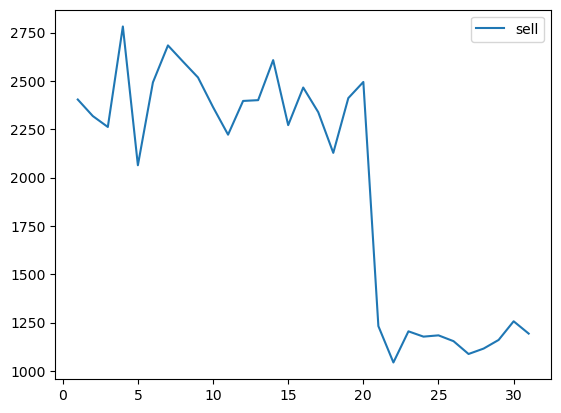

In [16]:
df.groupby(df.index.day).sum().plot();

<div class="alert alert-warning">В данном случае группировка выделила <b>только</b> дни и не выделила месяцы и мы получили неверные результаты.</div>

Правильнее будет так:

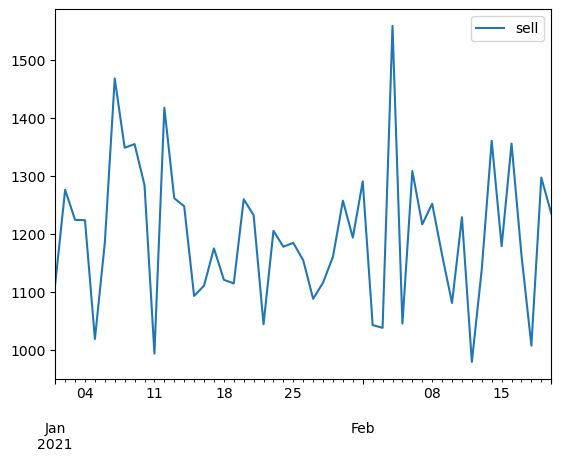

In [17]:
df.groupby(pd.to_datetime(df.index).to_period('D')).sum().plot();

In [18]:
df.groupby(pd.to_datetime(df.index).to_period('D')).sum()[:10]

,sell
2021-01-01,1113.627906
2021-01-02,1275.771914
2021-01-03,1223.945497
2021-01-04,1223.339108
2021-01-05,1018.648472
2021-01-06,1184.413457
2021-01-07,1467.455851
2021-01-08,1348.191204
2021-01-09,1354.473073
2021-01-10,1283.816098


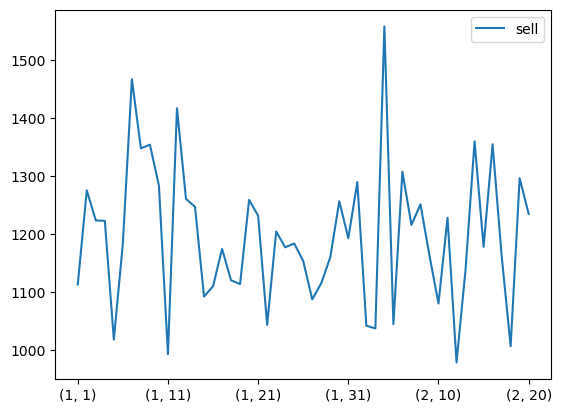

In [19]:
df.groupby([df.index.month, df.index.day]).sum().plot();

In [20]:
df.groupby([df.index.month, df.index.day]).sum()[:10]

sell
1 1   1113.627906
  2   1275.771914
  3   1223.945497
  4   1223.339108
  5   1018.648472
  6   1184.413457
  7   1467.455851
  8   1348.191204
  9   1354.473073
  10  1283.816098

In [21]:
pd.Series(df.index.weekday).value_counts()

4    192
5    191
6    168
0    168
1    168
2    168
3    168
Name: count, dtype: int64

In [22]:
df.groupby(df.index.weekday).count()

,sell
0,168
1,168
2,168
3,168
4,192
5,191
6,168


yfinance offers a threaded and Pythonic way to download market data from Yahoo!Ⓡ finance.

https://pypi.org/project/yfinance/ 

In [23]:
# !pip install yfinance

In [1]:
import yfinance as yf

In [2]:
msft = yf.download("MSFT", start="2020-01-01", end="2023-04-08")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [26]:
msft.shape

(822, 5)

In [27]:
msft.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [28]:
msft.head(5)

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500


Посчитаем среднюю за 50 дней цену закрытия

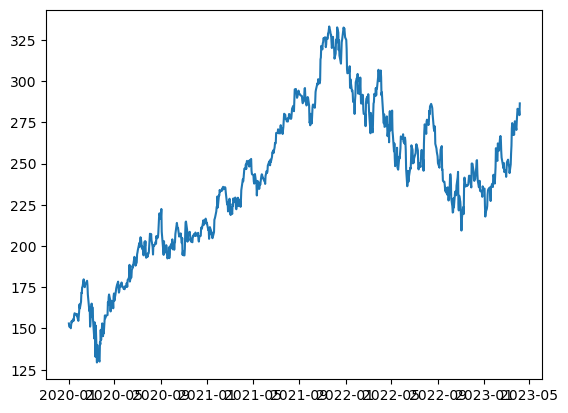

In [29]:
plt.plot(msft['Close'])
plt.show()

In [30]:
msft["SMA_50"] = msft["Close"].rolling(window=50).mean()

Нарисуем график, для демонстрации

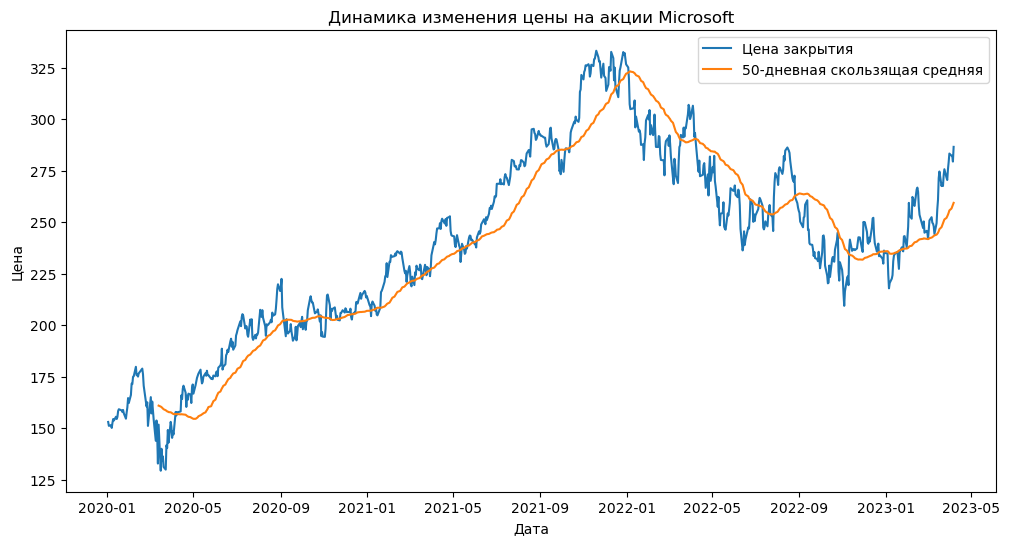

In [31]:
plt.figure(figsize=(12, 6)) 
plt.plot(msft["Close"], label="Цена закрытия")
plt.plot(msft["SMA_50"], label="50-дневная скользящая средняя") 
plt.title("Динамика изменения цены на акции Microsoft") 
plt.xlabel("Дата")
plt.ylabel("Цена") 
plt.legend() 
plt.show()

Наряду с поиском устойчивых трендов, при помощи скользящей средней, анализ временных рядов также связан с изучением динамики относительных изменений исследуемых показателей. Это может включать в себя вычисление процентного изменения показателей относительно предыдущих значений, что позволяет выявить сезонность, цикличность и другие закономерности в изменениях показателей. Такой анализ может помочь более точно оценить, насколько значимы изменения в показателях, а также сделать более обоснованные выводы на основе данных временных рядов.

В Pandas для создания лаговых переменных можно использовать метод `shift()`. Он смещает данные на указанное количество строк вверх или вниз. Это полезно, когда нужно сравнить значения на текущей строке с предыдущими или будущими значениями. Например, мы можем сместить данные на одну строку вниз, чтобы сравнить значения на текущей строке с предыдущей строкой. Мы также можем сместить данные на несколько строк вверх, чтобы сравнить значения на текущей строке с будущими значениями. 

Лаговые переменные часто используются для расчета разностей между текущими и предыдущими значениями временного ряда. Это полезно при анализе стационарности и сезонности в данных.

Мы можем использовать метод `shift()` и рассчитать показатель ежедневного колебания цены закрытия на акции в процентах.

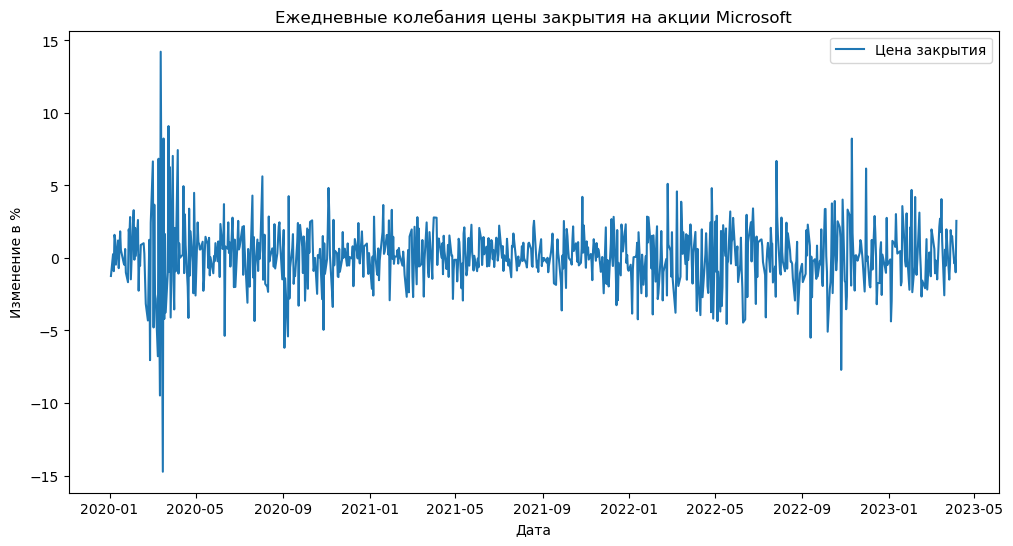

In [32]:
plt.figure(figsize=(12, 6))
plt.plot((msft.Close/msft.Close.shift(1) - 1)*100, label="Цена закрытия") 
plt.title("Ежедневные колебания цены закрытия на акции Microsoft") 
plt.xlabel("Дата")
plt.ylabel("Изменение в %") 
plt.legend()
plt.show()

Также с помощью метода `shift()` можно вычислять среднемесячные или среднегодовые изменения исследуемых показателей.

Например, чтобы рассчитать среднемесячное изменение цены закрытия акций, можно использовать метод `shift()` с аргументом `freq=pd.DateOffset(months=1)`, чтобы сдвинуть цену закрытия на один месяц назад. Затем можно рассчитать отношение текущей цены закрытия к цене закрытия месяц назад и вычесть из него единицу, чтобы получить процентное изменение цены за месяц.

## Экспоненциальное сглаживание

In [33]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

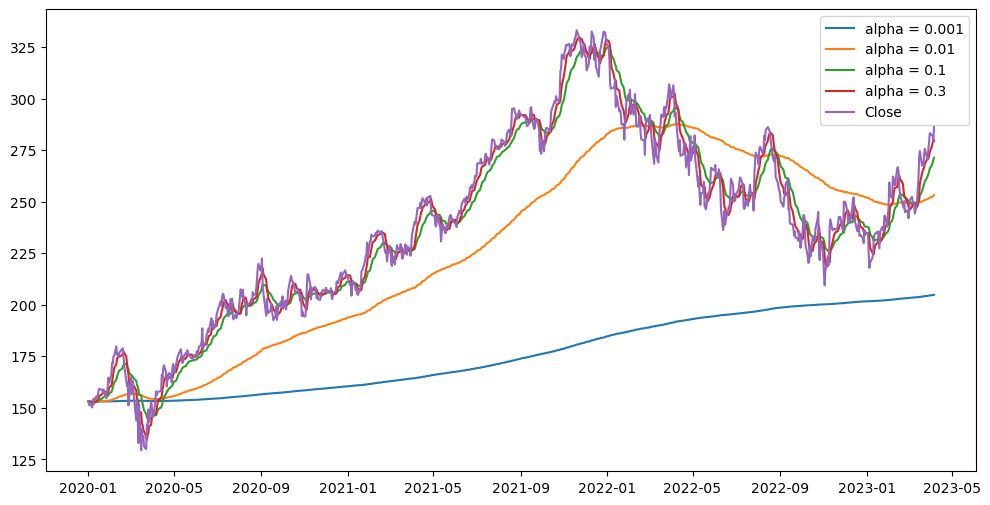

In [34]:

# Perform simple exponential smoothing
plt.figure(figsize=(12, 6))
model = SimpleExpSmoothing(np.asarray(msft['Close']))
model._index = pd.to_datetime(msft.index)
for alpha in [0.001, 0.01, 0.1, 0.3]:
    ses_model = model.fit(smoothing_level=alpha, optimized=False)
    name = 'ses_a_' + str(alpha)
    msft[name] = ses_model.fittedvalues
    plt.plot(msft[name], label=f'alpha = {alpha}')

plt.plot(msft['Close'], label='Close')
plt.legend()
plt.show()


# Анализ временных рядов

Условия стационарности:
- У ряда отсутствует тренд
- У ряда отсутствует сезонность
- У ряда не изменяется дисперсия

Тренд — это общее поведение ряда. Например постепенно среднее значение увеличивается от 100 до 400–450.

Сезонность. Замеры раз в 12 месяцев сильно похожи друг на друга. Например, пики на графики наблюдаются в один и тот же месяц.

Дисперсия. В начале и в течение года данные не сильно изменялись. А под конец максимальный замер уже значительно отличается от минимального.

Первый шаг в анализе временных рядов — проверка стационарности. Для этого существует несколько статистических тестов. 
- Тест Дики-Фуллера;
- Тест Филипса — Перрона;
- Тест Лейбурна;
- Тест Шмидта — Филлипса;
- Тест Квятковского — Филлипса — Шмидта — Шина;
- Тест DF — GLS;
- Тест Кохрейн.

Воспользуемся тестом Дики-Фуллера.

In [35]:
from statsmodels.tsa.stattools import adfuller

In [36]:
test = adfuller(msft['Close'])

In [37]:
test

(np.float64(-1.793246354028292),
 np.float64(0.3838198090477183),
 9,
 812,
 {'1%': np.float64(-3.4384289321263126),
  '5%': np.float64(-2.865105979079729),
  '10%': np.float64(-2.568668841575869)},
 np.float64(4754.139109993895))

In [38]:
if test[0]>test[4]['5%']:
    print('Ряд не стационарен')
else:
    print('OK, ряд стационарен')

Ряд не стационарен


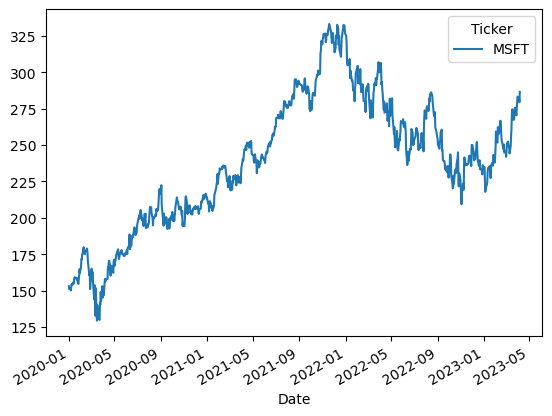

In [39]:
msft['Close'].plot();

Ряд оказался нестационарным. Что делать?
Начать преобразования ряда стоит с последнего пункта — меняющейся во времени дисперсии. 

Те, кто хорошо знаком с математикой, понимают, что в этом может помочь логарифмирование ряда. Но лучшим образом для этого подойдет преобразование Бокса-Кокса:

$$
y =
  \begin{cases}
    \frac{y^{\lambda}-1}{\lambda}       & \quad \lambda=0\\
    \ln{y}  & \quad \lambda \neq 0
  \end{cases}

$$

Для его работы нужно определить $λ$. И если $λ = 0$, то будет применено обычное логарифмирование.
В `Python` есть реализация этого преобразования с автоматическим подбором оптимального $λ$.

In [40]:
from scipy import stats

In [57]:
# Преобразование
s, l = stats.boxcox(msft['Close'].reset_index()['MSFT'])
msft['Close_log_' + str(np.round(l, 2))] = s

In [58]:
l

np.float64(1.207921643485623)

In [59]:
msft.head()

Price,Close,High,Low,Open,Volume,SMA_50,ses_a_0.001,ses_a_0.01,ses_a_0.1,ses_a_0.3,Close_log_1.21
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,,,,
Date,,,,,,,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100,NaN,153.042297,153.042297,153.042297,153.042297,359.785902
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200,NaN,153.042297,153.042297,153.042297,153.042297,354.369019
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700,NaN,153.040392,153.023241,152.851732,152.470601,355.478405
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100,NaN,153.038879,153.008282,152.719292,152.187619,351.557935
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500,NaN,153.035986,152.979656,152.461936,151.575054,358.349080


In [66]:
msft.columns

MultiIndex([(         'Close', 'MSFT'),
            (          'High', 'MSFT'),
            (           'Low', 'MSFT'),
            (          'Open', 'MSFT'),
            (        'Volume', 'MSFT'),
            (        'SMA_50',     ''),
            (   'ses_a_0.001',     ''),
            (    'ses_a_0.01',     ''),
            (     'ses_a_0.1',     ''),
            (     'ses_a_0.3',     ''),
            ('Close_log_1.21',     '')],
           names=['Price', 'Ticker'])

In [67]:
msft[('Close_log_1.21',     '')]

Date
2020-01-02    359.785902
2020-01-03    354.369019
2020-01-06    355.478405
2020-01-07    351.557935
2020-01-08    358.349080
                 ...    
2023-03-31    757.786071
2023-04-03    754.386506
2023-04-04    754.227591
2023-04-05    745.217434
2023-04-06    768.287247
Name: (Close_log_1.21, ), Length: 822, dtype: float64

In [68]:
test = adfuller(msft[('Close_log_1.21',     '')])
if test[0]>test[4]['5%']:
    print('Ряд не стационарен')
else:
    print('OK, ряд стационарен')

Ряд не стационарен


Избавимся от сезонности.

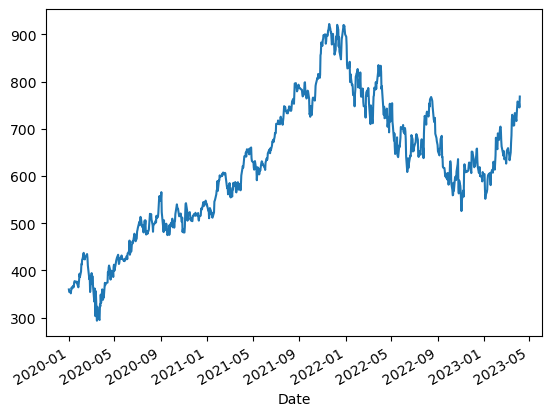

In [70]:
msft[('Close_log_1.21',     '')].plot();

In [71]:
msft['Сlose_season_diff'] = msft[('Close_log_1.21',     '')] - msft[('Close_log_1.21',     '')].shift(12)

In [72]:
msft.head()

Price,Close,High,Low,Open,Volume,SMA_50,ses_a_0.001,ses_a_0.01,ses_a_0.1,ses_a_0.3,Close_log_1.21,Сlose_season_diff
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,,,,,
Date,,,,,,,,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100,NaN,153.042297,153.042297,153.042297,153.042297,359.785902,NaN
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200,NaN,153.042297,153.042297,153.042297,153.042297,354.369019,NaN
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700,NaN,153.040392,153.023241,152.851732,152.470601,355.478405,NaN
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100,NaN,153.038879,153.008282,152.719292,152.187619,351.557935,NaN
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500,NaN,153.035986,152.979656,152.461936,151.575054,358.349080,NaN


In [73]:
msft['foo'] = msft['Close'] - msft['Close'].shift(2)
msft.head()

Price,Close,High,Low,Open,Volume,SMA_50,ses_a_0.001,ses_a_0.01,ses_a_0.1,ses_a_0.3,Close_log_1.21,Сlose_season_diff,foo
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,,,,,,
Date,,,,,,,,,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100,NaN,153.042297,153.042297,153.042297,153.042297,359.785902,NaN,NaN
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200,NaN,153.042297,153.042297,153.042297,153.042297,354.369019,NaN,NaN
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700,NaN,153.040392,153.023241,152.851732,152.470601,355.478405,NaN,-1.514969
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100,NaN,153.038879,153.008282,152.719292,152.187619,351.557935,NaN,-0.990906
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500,NaN,153.035986,152.979656,152.461936,151.575054,358.349080,NaN,1.009979


Обратите внимание: после этой операции в новом ряде из-за смещения будут значения NaN. От них нужно избавиться.

In [74]:
# msft.dropna(inplace=True)
msft.fillna(value=0, inplace=True)
msft.head()

Price,Close,High,Low,Open,Volume,SMA_50,ses_a_0.001,ses_a_0.01,ses_a_0.1,ses_a_0.3,Close_log_1.21,Сlose_season_diff,foo
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,,,,,,
Date,,,,,,,,,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100,0.0,153.042297,153.042297,153.042297,153.042297,359.785902,0.0,0.000000
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200,0.0,153.042297,153.042297,153.042297,153.042297,354.369019,0.0,0.000000
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700,0.0,153.040392,153.023241,152.851732,152.470601,355.478405,0.0,-1.514969
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100,0.0,153.038879,153.008282,152.719292,152.187619,351.557935,0.0,-0.990906
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500,0.0,153.035986,152.979656,152.461936,151.575054,358.349080,0.0,1.009979


In [75]:
test = adfuller(msft['Сlose_season_diff'])
if test[0]>test[4]['5%']:
    print('Ряд не стационарен')
else:
    print('OK, ряд стационарен')

OK, ряд стационарен


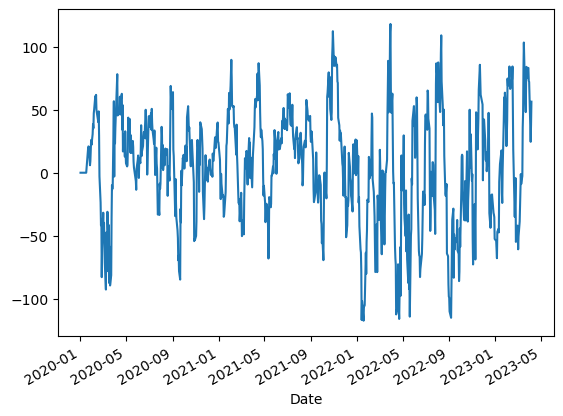

In [76]:
msft['Сlose_season_diff'].plot();

Если после сезонного дифференцирования сезонность в данных осталась, проведите ещё одно сезонное дифференцирование. Но уже с новым продифференцированным рядом.

И повторяйте, пока сезонности не останется. На практике, у меня ни разу не было такого, чтобы я делал сезонное дифференцирование больше двух раз. Но не нужно делать дифференцирование больше, чем необходимо. Если после первого раза сезонность пропала — оставьте его.

Далее тренд. Чтобы избавиться от него, применяем обычное дифференцирование. То есть при вычитании сдвигаем ряд на 1. И проводим дифференцирование, пока ряд не станет стационарным:

In [77]:
msft['Close_trend_diff'] = msft['Сlose_season_diff'] - msft['Сlose_season_diff'].shift(1)

In [78]:
msft.head()

Price,Close,High,Low,Open,Volume,SMA_50,ses_a_0.001,ses_a_0.01,ses_a_0.1,ses_a_0.3,Close_log_1.21,Сlose_season_diff,foo,Close_trend_diff
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,,,,,,,
Date,,,,,,,,,,,,,,
2020-01-02,153.042297,153.147108,150.860341,151.289108,22622100,0.0,153.042297,153.042297,153.042297,153.042297,359.785902,0.0,0.000000,NaN
2020-01-03,151.136642,152.403898,150.603064,150.850807,21116200,0.0,153.042297,153.042297,153.042297,153.042297,354.369019,0.0,0.000000,0.0
2020-01-06,151.527328,151.594033,149.126212,149.669328,20813700,0.0,153.040392,153.023241,152.851732,152.470601,355.478405,0.0,-1.514969,0.0
2020-01-07,150.145737,152.137132,149.898008,151.803653,21634100,0.0,153.038879,153.008282,152.719292,152.187619,351.557935,0.0,-0.990906,0.0
2020-01-08,152.537308,153.213818,150.498269,151.432030,27746500,0.0,153.035986,152.979656,152.461936,151.575054,358.349080,0.0,1.009979,0.0


In [79]:
msft.dropna(inplace=True)

## Декомпозиция ряда на сезон и тренд

In [80]:
from statsmodels.tsa.seasonal import seasonal_decompose
# произведем декомпозицию временного ряда 

decomposition = seasonal_decompose(msft['Close'], period=30)

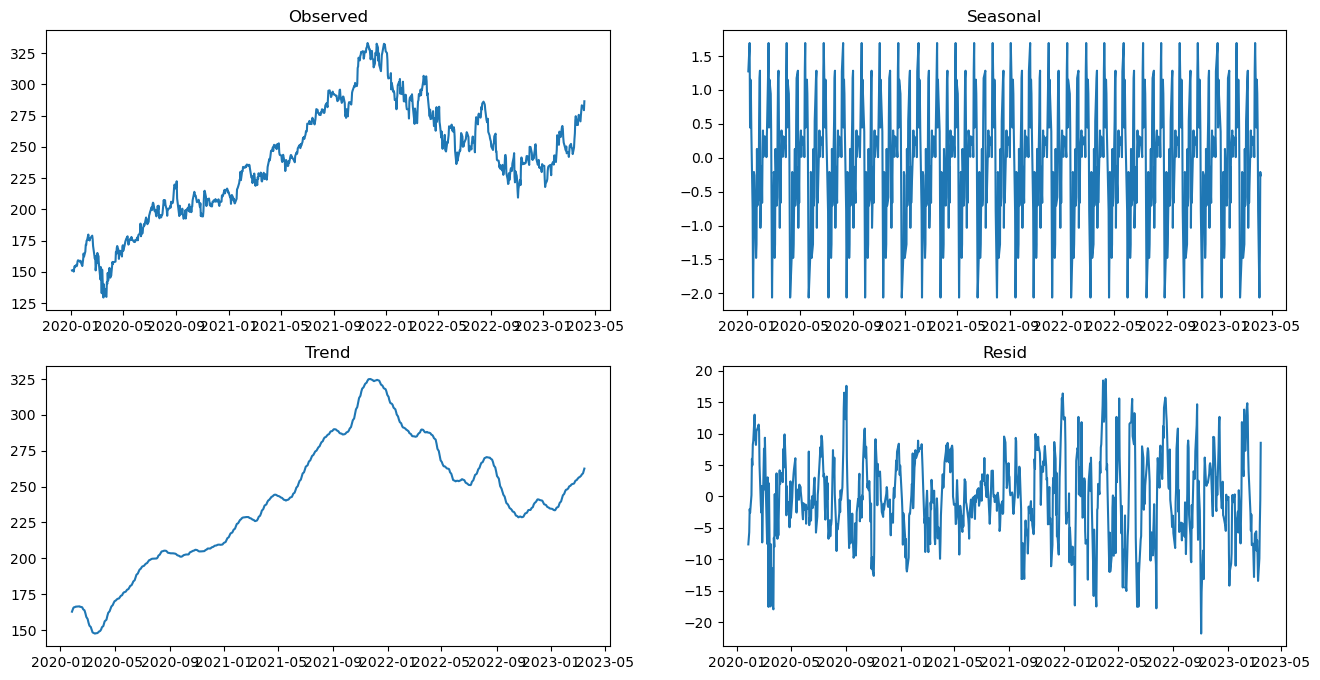

In [81]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

axs[0, 0].plot(decomposition.observed)
axs[0, 0].set_title('Observed')
axs[1, 0].plot(decomposition.trend)
axs[1, 0].set_title('Trend')
axs[0, 1].plot(decomposition.seasonal)
axs[0, 1].set_title('Seasonal')
axs[1, 1].plot(decomposition.resid)
axs[1, 1].set_title('Resid')
# axs[1, 1].set_xlabel('Date')
# fig.savefig('decomp.jpg')
plt.show()